In [ ]:
import requests
import json
import os
import math
import random
from glob import glob
import os
import shutil
import random
from glob import glob


In [ ]:

OVERPASS_URL = "https://overpass.kumi.systems/api/interpreter"
HEADERS = {"User-Agent": "nl-road-fetcher/2.0"}
API_KEY = "" # Google API KEY


#OSM Queries
QUERIES = {
    "fietsstraat": r"""
        [out:json][timeout:120];
        area["ISO3166-1"="NL"]->.nl;
        way["cyclestreet"="yes"](area.nl);
        out tags geom;
    """,

    "snelweg": r"""
        [out:json][timeout:120];
        area["ISO3166-1"="NL"]->.nl;
        way["highway"="motorway"](area.nl);
        out tags geom;
    """,

    "rural": r"""
        [out:json][timeout:120];
        area["ISO3166-1"="NL"]->.nl;
        (
          way["highway"="unclassified"]["maxspeed"="60"](area.nl);
          way["highway"="tertiary"]["maxspeed"="60"](area.nl);
        );
        out tags geom;
    """
}


def load_or_fetch_osm(cat):
    file = f"osm_{cat}_nl.json"

    if os.path.exists(file):
        print(f"{file} bestaat al -> laden i.p.v. opnieuw downloaden")
        with open(file) as f:
            return json.load(f)

    print(f"OSM ophalen voor {cat}")
    r = requests.get(OVERPASS_URL, params={"data": QUERIES[cat]}, headers=HEADERS)

    if r.status_code != 200:
        print("Overpass error:", r.text[:400])
        return {}

    try:
        osm = r.json()
    except:
        print("Geen geldige JSON:", r.text[:400])
        return {}

    elements = {}
    for el in osm.get("elements", []):
        if el.get("type") != "way":
            continue
        way_id = str(el["id"])
        coords = [{"lat": g["lat"], "lon": g["lon"]} for g in el.get("geometry", [])]

        elements[way_id] = {
            "id": way_id,
            "name": el.get("tags", {}).get("name"),
            "highway": el.get("tags", {}).get("highway"),
            "coords": coords
        }

    # Opslaan naar JSON
    with open(file, "w") as f:
        json.dump(elements, f, indent=2)

    print(f"OSM opgeslagen: {file} ({len(elements)} ways)")
    return elements


# Heading 
def calc_heading(lat1, lon1, lat2, lon2):
    dlon = math.radians(lon2 - lon1)
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)
    y = math.sin(dlon) * math.cos(lat2)
    x = math.cos(lat1)*math.sin(lat2) - math.sin(lat1)*math.cos(lat2)*math.cos(dlon)
    return (math.degrees(math.atan2(y, x)) + 360) % 360


# Street View download
def download_sv(lat, lon, heading, save_as):
    url = "https://maps.googleapis.com/maps/api/streetview"
    params = {
        "size": "640x640",
        "location": f"{lat},{lon}",
        "heading": heading,
        "fov": 60,
        "pitch": 0,
        "source": "outdoor",
        "key": API_KEY
    }
    r = requests.get(url, params=params)

    if r.status_code == 200 and "image" in r.headers.get("Content-Type", ""):
        with open(save_as, "wb") as f:
            f.write(r.content)
        print(f"Opgeslagen {save_as}")
        return True

    print(f"Geen Street View ({r.status_code})")
    return False


# Category downloader
def download_category(cat, ways, target_count=1000):
    out_dir = f"./output/{cat}"
    os.makedirs(out_dir, exist_ok=True)

    existing_files = glob(out_dir + "/*.jpg")
    existing_ids = {os.path.splitext(os.path.basename(f))[0] for f in existing_files}

    print(f"\n=== {cat.upper()} ===")
    print(f"Reeds bestaande foto's: {len(existing_ids)}")

    remaining = target_count - len(existing_ids)
    if remaining <= 0:
        print("Al 1000+ bestanden skip categorie")
        return

    print(f"Moet nog downloaden: {remaining}")

    # Alle ways randomizen
    keys = list(ways.keys())
    random.shuffle(keys)

    count = 0

    for way_id in keys:
        if count >= remaining:
            break

        if way_id in existing_ids:
            continue

        coords = ways[way_id]["coords"]
        if len(coords) < 2:
            continue

        lat1, lon1 = coords[0]["lat"], coords[0]["lon"]
        lat2, lon2 = coords[1]["lat"], coords[1]["lon"]

        heading = calc_heading(lat1, lon1, lat2, lon2)
        save_as = f"{out_dir}/{way_id}.jpg"

        ok = download_sv(lat2, lon2, heading, save_as)
        if ok:
            count += 1

    print(f"KLAAR met {cat}: {count} nieuwe downloads")


# MAIN
def main():
    # Load or fetch OSM
    fiets = load_or_fetch_osm("fietsstraat")
    snelweg = load_or_fetch_osm("snelweg")
    rural = load_or_fetch_osm("rural")

    # Download afbeeldingen
    download_category("fietsstraat", fiets, 1000)
    download_category("snelweg", snelweg, 1000)
    download_category("rural", rural, 1000)

    print("\n=== ALLES KLAAR ===")


if __name__ == "__main__":
    main()


osm_fietsstraat_nl.json bestaat al → laden i.p.v. opnieuw downloaden
osm_snelweg_nl.json bestaat al → laden i.p.v. opnieuw downloaden
osm_rural_nl.json bestaat al → laden i.p.v. opnieuw downloaden

=== FIETSSTRAAT ===
Reeds bestaande foto's: 1000
Al 1000+ bestanden skip categorie

=== SNELWEG ===
Reeds bestaande foto's: 1000
Al 1000+ bestanden skip categorie

=== RURAL ===
Reeds bestaande foto's: 1000
Al 1000+ bestanden skip categorie

=== ALLES KLAAR ===


In [ ]:

SOURCE_DIR = "./output_selected" 
TARGET_DIR = "./dataset"

CATEGORIES = ["fietsstraat", "snelweg", "rural"]

TRAIN_SPLIT = 0.8
SEED = 1337                       # <-- vaste seed = repliceerbaar
CLEAN_TARGET = True               # <-- target eerst leegmaken

IMG_EXTS = (".jpg", ".jpeg", ".png", ".webp")


def list_images(folder):
    if not os.path.exists(folder):
        return []
    return [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]


def safe_rmtree(path):
    if os.path.exists(path):
        shutil.rmtree(path)


def build_yolo_classification_dataset():
    print("Opbouw van YOLO Dataset")
    print(f"Source: {SOURCE_DIR}")
    print(f"Target: {TARGET_DIR}")
    print(f"Seed:   {SEED}")
    print(f"Split:  {TRAIN_SPLIT*100:.0f}% train / {(1-TRAIN_SPLIT)*100:.0f}% val\n")

    rng = random.Random(SEED)

    # Clean target
    if CLEAN_TARGET:
        safe_rmtree(TARGET_DIR)

    # Create folders
    for subset in ["train", "val"]:
        for cat in CATEGORIES:
            os.makedirs(os.path.join(TARGET_DIR, subset, cat), exist_ok=True)

    # Gather files per category
    files_by_cat = {}
    counts = {}

    for cat in CATEGORIES:
        src = os.path.join(SOURCE_DIR, cat)
        files = list_images(src)

        if not files:
            print(f"Geen bestanden voor categorie '{cat}' in {src}")
            files_by_cat[cat] = []
            counts[cat] = 0
            continue

        files_by_cat[cat] = files
        counts[cat] = len(files)

    # Determine balanced sample size = minimum count across categories
    min_count = min(counts.values()) if counts else 0
    if min_count == 0:
        raise RuntimeError(f"Min count is 0 , check je mappen in {SOURCE_DIR}/<cat>/")

    print("Counts per class:")
    for cat in CATEGORIES:
        print(f"  {cat:12s}: {counts[cat]}")
    print(f"\nBalanced sample size per class: {min_count}\n")

    # Sample balanced subset per category (replicable)
    selected_by_cat = {}
    for cat in CATEGORIES:
        files = files_by_cat[cat][:]
        rng.shuffle(files)                  # vaste shuffle
        selected = files[:min_count]        # neem exact min_count
        selected_by_cat[cat] = selected

    # Split each category into train/val using the same RNG
    for cat in CATEGORIES:
        selected = selected_by_cat[cat][:]
        # extra shuffle om split niet 100% gekoppeld te laten aan eerder order
        rng.shuffle(selected)

        train_count = int(min_count * TRAIN_SPLIT)
        train_files = selected[:train_count]
        val_files = selected[train_count:]

        print(f"Categorie: {cat}")
        print(f"Selected: {len(selected)}")
        print(f"Train:    {len(train_files)}")
        print(f"Val:      {len(val_files)}")

        src_dir = os.path.join(SOURCE_DIR, cat)

        # Copy train
        for f in train_files:
            shutil.copy2(
                os.path.join(src_dir, f),
                os.path.join(TARGET_DIR, "train", cat, f),
            )

        # Copy val
        for f in val_files:
            shutil.copy2(
                os.path.join(src_dir, f),
                os.path.join(TARGET_DIR, "val", cat, f),
            )

        print("")

    print("Dataset gebouwd (balanced + reproduceerbaar)")
    print(f"Output: {TARGET_DIR}/train en {TARGET_DIR}/val")
    print("Klaar voor YOLOv8/YOLOv9 classification training")


if __name__ == "__main__":
    build_yolo_classification_dataset()


=== Building BALANCED YOLO classification dataset (replicable) ===
Source: ./output_selected
Target: ./dataset
Seed:   1337
Split:  80% train / 20% val

Counts per class:
  fietsstraat : 731
  snelweg     : 987
  rural       : 825

=> Balanced sample size per class: 731

Categorie: fietsstraat
Selected: 731
Train:    584
Val:      147

Categorie: snelweg
Selected: 731
Train:    584
Val:      147

Categorie: rural
Selected: 731
Train:    584
Val:      147

Dataset gebouwd (balanced + reproduceerbaar)
Output: ./dataset/train en ./dataset/val
Klaar voor YOLOv8/YOLOv9 classification training


In [ ]:
from ultralytics import YOLO

# Kies een goed YOLOv8 classification model
model = YOLO("yolov8m-cls.pt")

#model.train(
#    data="dataset",
#    epochs=3,
#    imgsz=640,
#    batch=2,     # lager
#    device=0,
#    workers=0,
#    amp=False,    # uit
#    val=False,    # uit (scheelt gedoe + jouw eerdere crash zat daar)
#    verbose=True
#)

## Betere parameters 
model.train(
    data="dataset",
    epochs=60,
    patience=10,
    imgsz=512,          
    batch=16,
    device=0,
    workers=0,
    amp=True,
    val=True,
    verbose=True
)

print("Training klaar!")
print("Resultaten in ./runs/classify/")


Ultralytics 8.4.14  Python-3.12.0 torch-2.9.1+rocmsdk20260116 CUDA:0 (AMD Radeon RX 7900 XTX, 24560MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train14, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspectiv

In [4]:
import torch; print(f'device name [0]:', torch.cuda.get_device_name(0))

device name [0]: AMD Radeon RX 7900 XTX


In [25]:
model.export(format="onnx")

Ultralytics 8.4.14  Python-3.12.0 torch-2.9.1+rocmsdk20260116 CPU (Intel Core Ultra 7 265K)

PyTorch: starting from 'runs\classify\train14\weights\best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 3) (30.2 MB)

ONNX: starting export with onnx 1.20.1 opset 22...


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.85...
ONNX: export success  1.2s, saved as 'runs\classify\train14\weights\best.onnx' (60.2 MB)

Export complete (1.4s)
Results saved to C:\Users\Admin\Desktop\Artificial Intelligence\runs\classify\train14\weights
Predict:         yolo predict task=classify model=runs\classify\train14\weights\best.onnx imgsz=512 
Validate:        yolo val task=classify model=runs\classify\train14\weights\best.onnx imgsz=512 data=dataset  
Visualize:       https://netron.app


'runs\\classify\\train14\\weights\\best.onnx'

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Laad beste model
model = YOLO("runs/classify/train14/weights/best.pt")

# Voer validatie opnieuw uit om de confusion matrix te genereren
results = model.val(
    imgsz=640,
    batch=8,
    workers=0,
    plots=True 
)





Ultralytics 8.4.14  Python-3.12.0 torch-2.9.1+rocmsdk20260116 CUDA:0 (AMD Radeon RX 7900 XTX, 24560MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,766,499 parameters, 0 gradients, 41.6 GFLOPs
train: C:\Users\Admin\Desktop\Artificial Intelligence\dataset\train... found 1752 images in 3 classes  
val: C:\Users\Admin\Desktop\Artificial Intelligence\dataset\val... found 441 images in 3 classes  
test: None...
val: Fast image access  (ping: 0.00.0 ms, read: 1312.8455.5 MB/s, size: 74.7 KB)
val: Scanning C:\Users\Admin\Desktop\Artificial Intelligence\dataset\val... 441 images, 0 corrupt: 100% ━━━━━━━━━━━━ 441/441  0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 56/56 14.6it/s 3.8s0.1s
                   all      0.948          1
Speed: 0.8ms preprocess, 2.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to C:\Users\Admin\Desktop\Artificial Intelligence\runs\classify\val5


In [9]:
DATASET_PATH = "dataset"
MODEL_PATH = "runs/classify/train14/weights/best.pt"


C:\Users\Admin\Desktop\Artificial Intelligence\runs\classify\val5


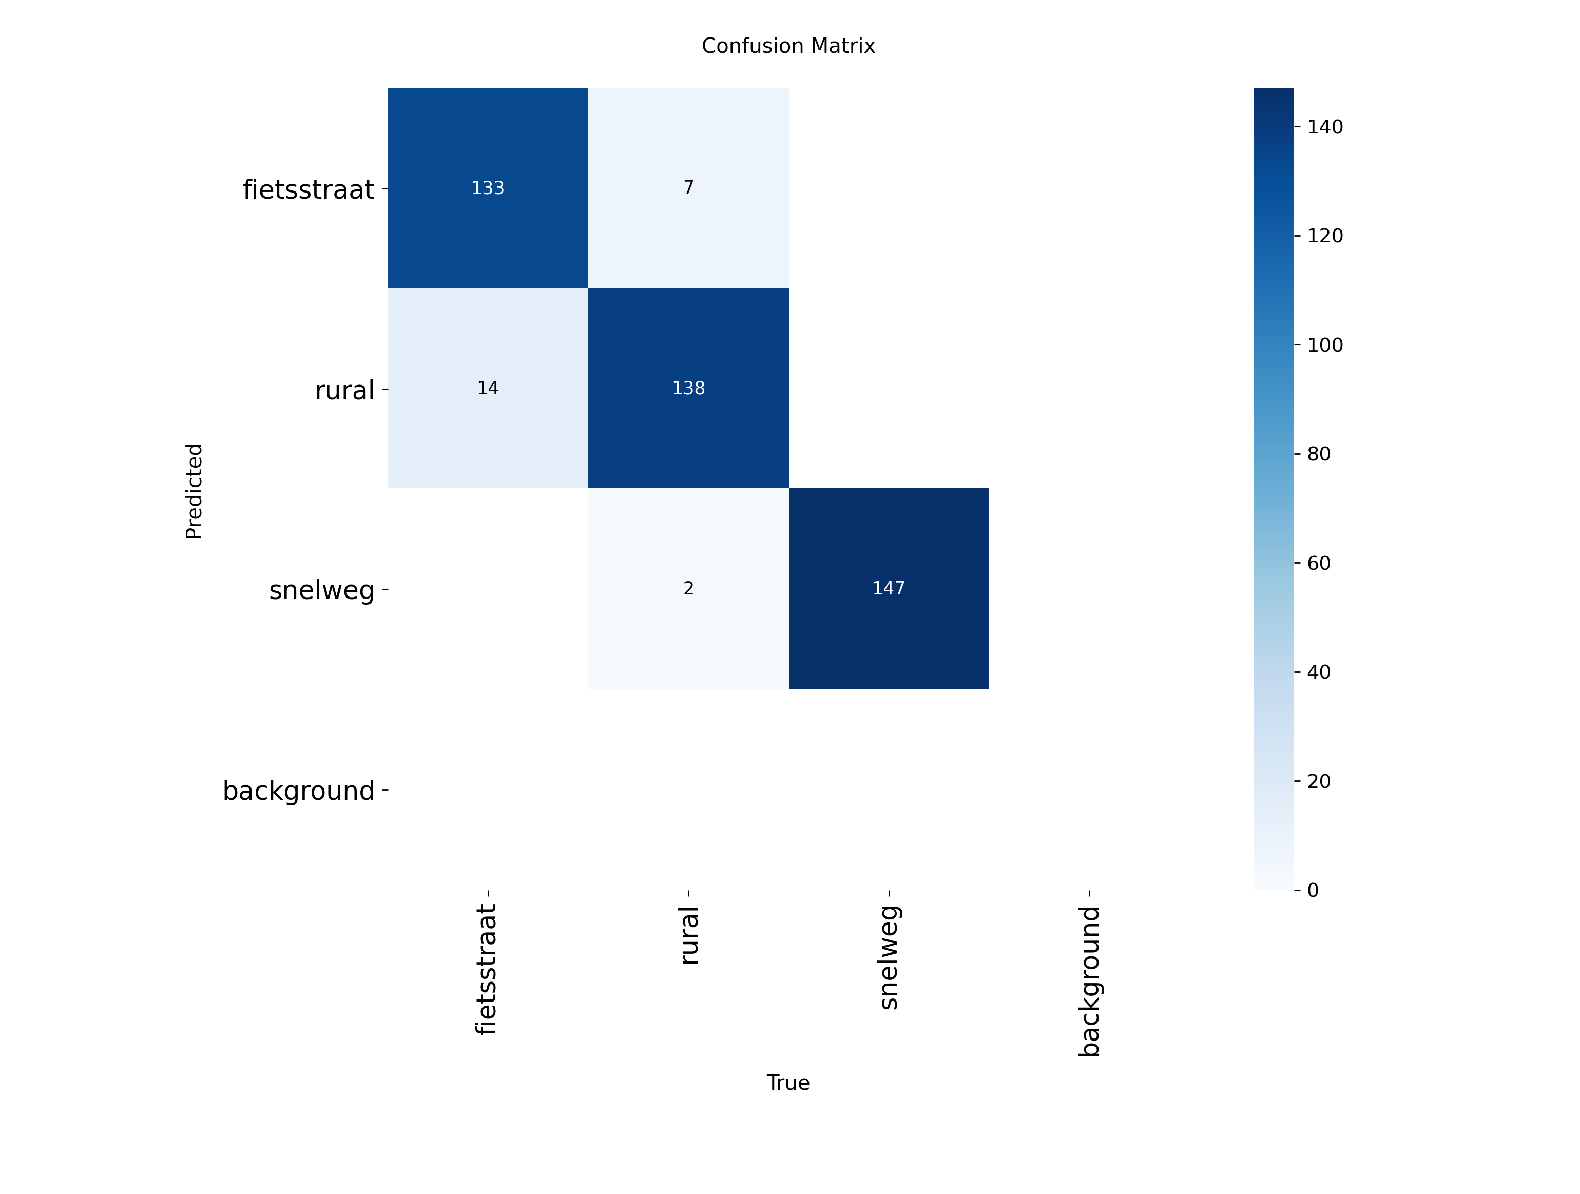

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
print(results.save_dir)
# Pad naar opgeslagen confusion matrix
cm_path = results.save_dir / "confusion_matrix.png"

# Open afbeelding
img = Image.open(cm_path)

# Toon in hogere kwaliteit
plt.figure(figsize=(8, 8), dpi=200)  # grotere figuur + hogere DPI
plt.imshow(img, interpolation='nearest')  # geen smoothing
plt.axis('off')
plt.tight_layout()
plt.show()

In [11]:
import os
import glob
import numpy as np

classes = sorted(os.listdir(f"{DATASET_PATH}/val"))
class_to_idx = {c: i for i, c in enumerate(classes)}

y_true = []
file_paths = []

for cls in classes:
    imgs = glob.glob(f"{DATASET_PATH}/val/{cls}/*")
    for img in imgs:
        y_true.append(class_to_idx[cls])
        file_paths.append(img)

y_true = np.array(y_true)

In [12]:
print("Aantal val-images:", len(y_true))
print("Klassen:", classes)


Aantal val-images: 441
Klassen: ['fietsstraat', 'rural', 'snelweg']


In [13]:
from ultralytics import YOLO
import numpy as np

model = YOLO(MODEL_PATH)

probs = []
y_pred = []

pred_results = model.predict(file_paths, verbose=False)

for p in pred_results:
    prob = p.probs.data.cpu().numpy()
    probs.append(prob)
    y_pred.append(np.argmax(prob))

probs = np.array(probs)
y_pred = np.array(y_pred)


In [14]:
from sklearn.preprocessing import label_binarize

num_classes = len(classes)
y_true_oh = label_binarize(y_true, classes=list(range(num_classes)))

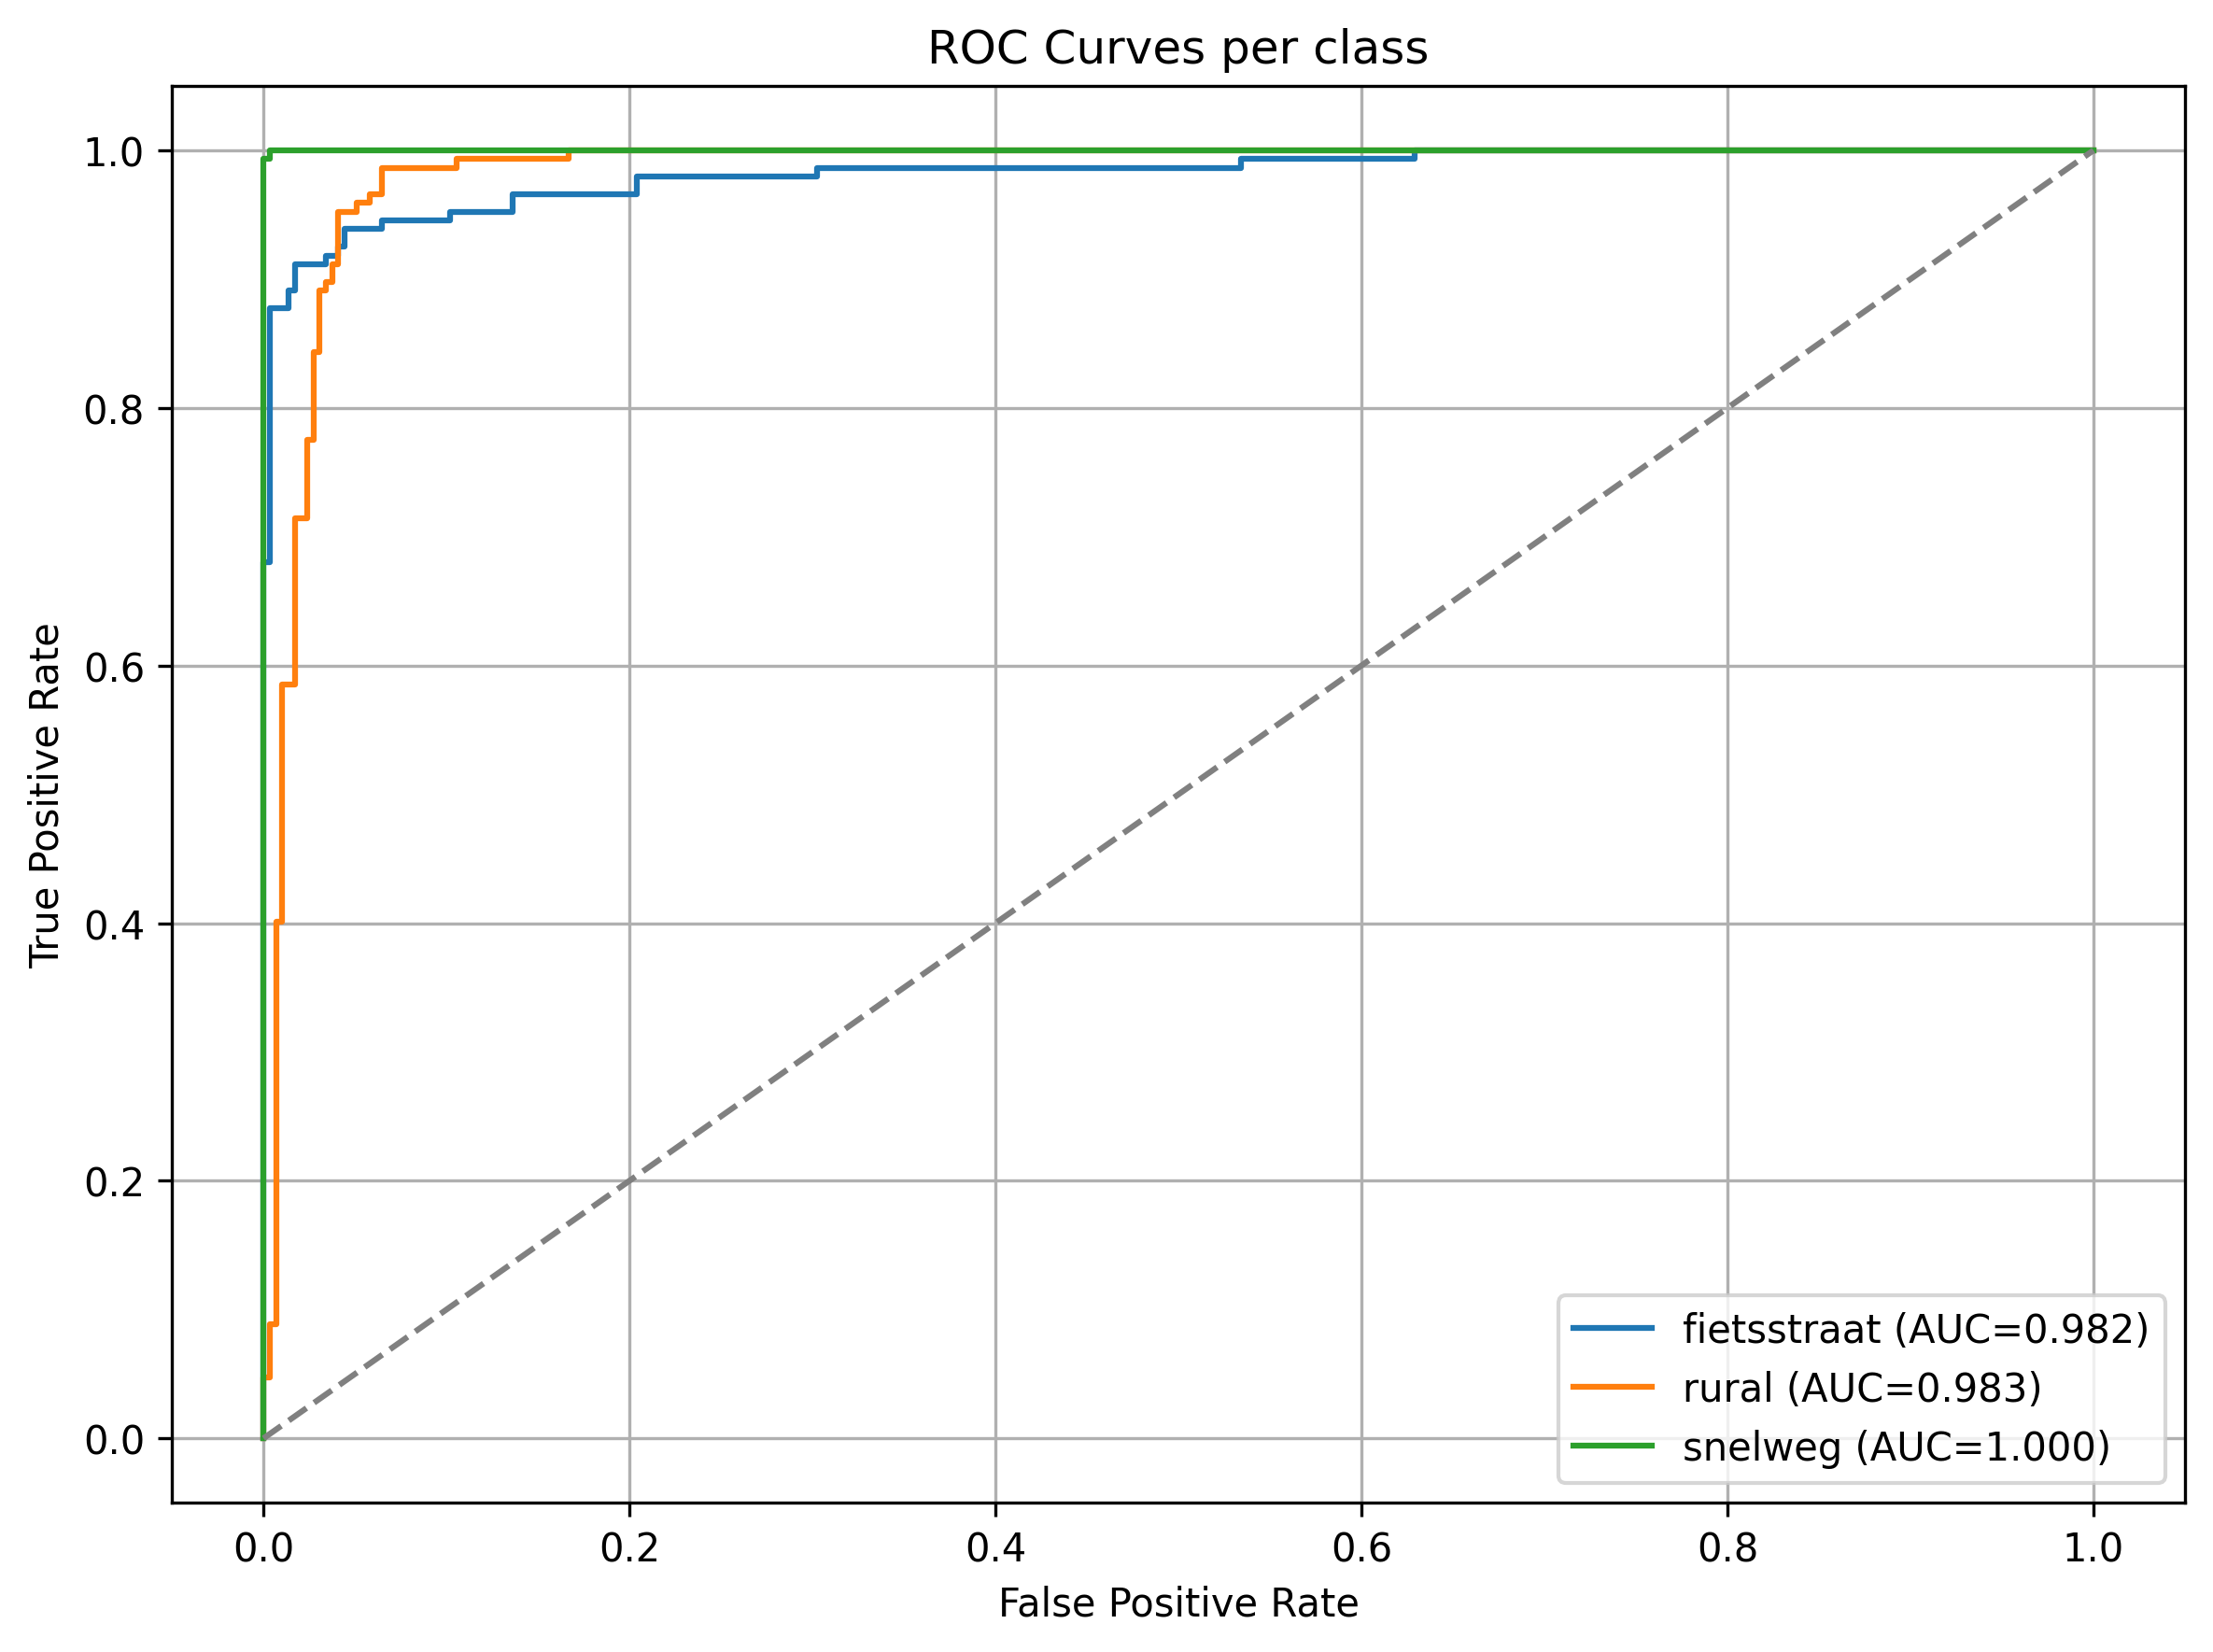

In [23]:
import os
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Maak map aan als die nog niet bestaat
output_dir = "latex_outputs"
os.makedirs(output_dir, exist_ok=True)

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8,6), dpi=300)

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_oh[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f"{classes[i]} (AUC={roc_auc[i]:.3f})")

plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves per class")
plt.legend()
plt.grid(True)

# Hoge kwaliteit opslaan
plt.tight_layout()
plt.savefig(f"{output_dir}/roc_curves.pdf")          # Beste voor LaTeX (vector)
plt.savefig(f"{output_dir}/roc_curves.png", dpi=600) # Hoge resolutie PNG

plt.show()


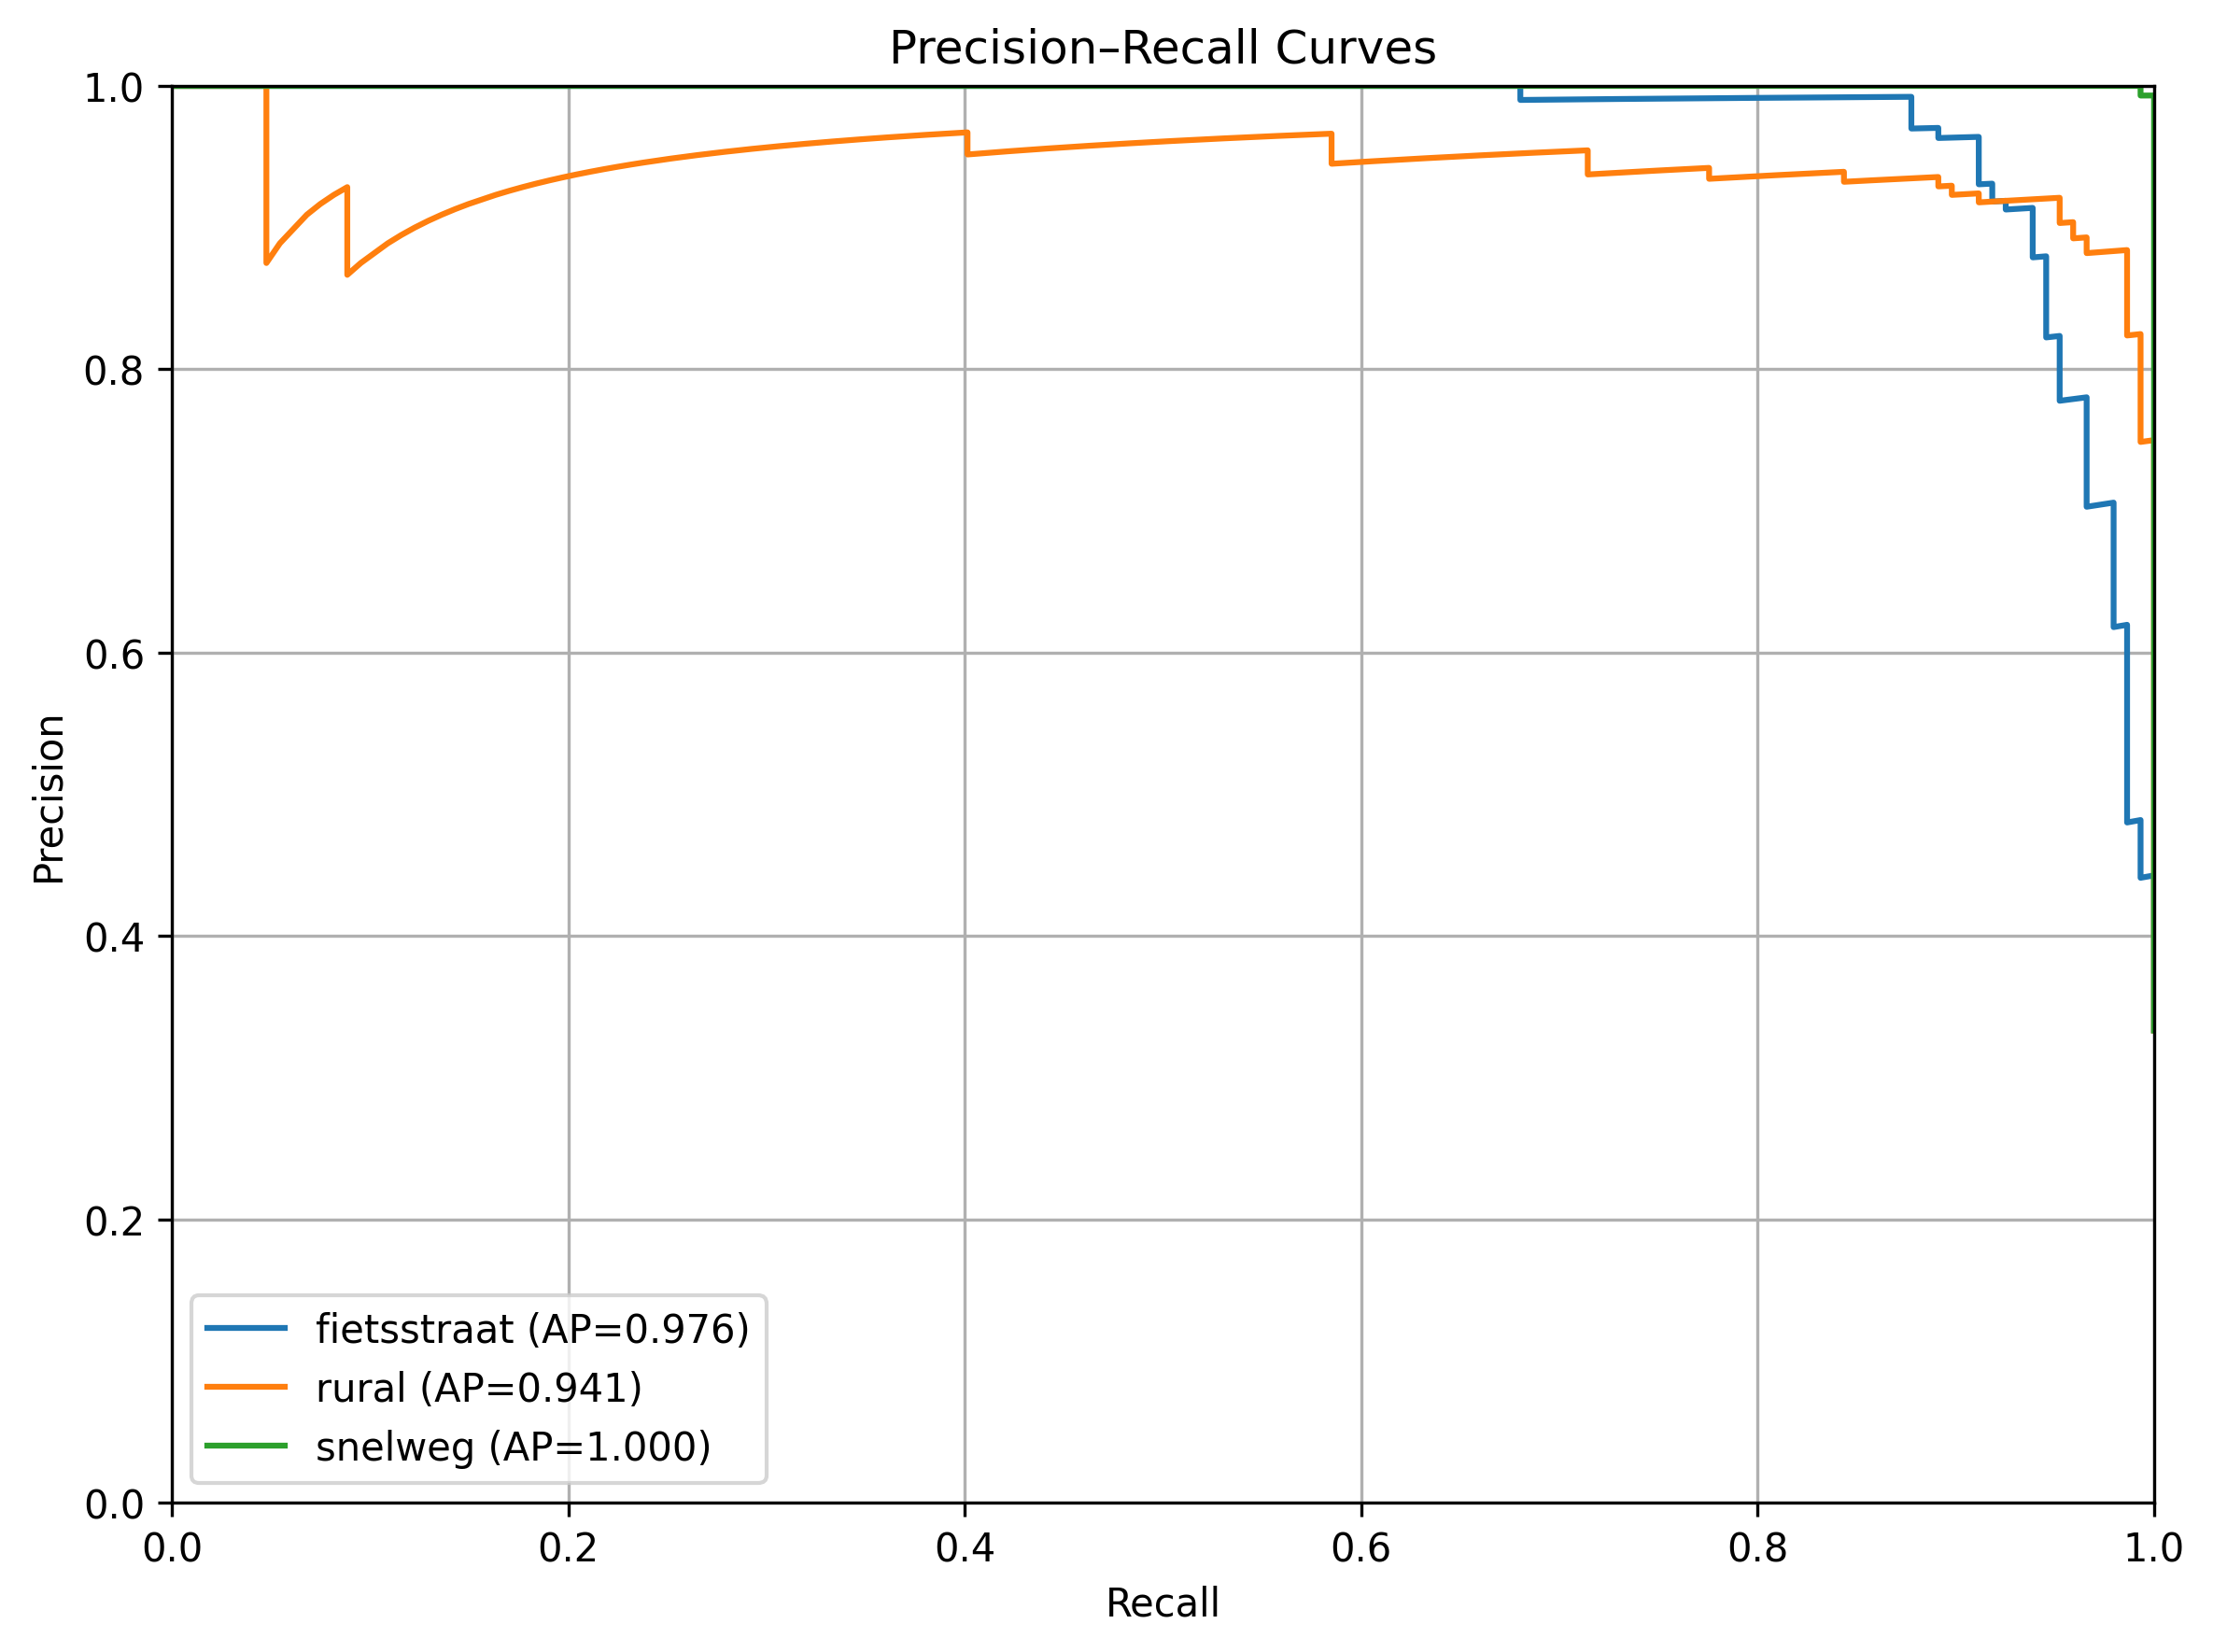

In [24]:
import os
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Maak map aan als die nog niet bestaat
output_dir = "latex_outputs"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(8,6), dpi=300)

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_oh[:, i], probs[:, i])
    ap = average_precision_score(y_true_oh[:, i], probs[:, i])

    plt.plot(recall, precision, label=f"{classes[i]} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.tight_layout()

# Hoge kwaliteit opslaan
plt.savefig(f"{output_dir}/precision_recall_curves.pdf")          # Beste voor LaTeX (vector)
plt.savefig(f"{output_dir}/precision_recall_curves.png", dpi=600) # Hoge resolutie PNG

plt.show()





In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=classes))


              precision    recall  f1-score   support

 fietsstraat       0.96      0.91      0.94       147
       rural       0.92      0.95      0.93       147
     snelweg       0.99      1.00      0.99       147

    accuracy                           0.95       441
   macro avg       0.96      0.95      0.95       441
weighted avg       0.96      0.95      0.95       441

